In [118]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import warnings

In [119]:
warnings.filterwarnings('ignore')

In [120]:
data=pd.read_csv('E:/Restaurant_Reviews.tsv',sep='\t')

In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [122]:
data.isnull().sum()

Review    0
Liked     0
dtype: int64

In [123]:
data.head(5)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [124]:
data.shape

(1000, 2)

In [125]:
data['Liked'].value_counts()

1    500
0    500
Name: Liked, dtype: int64

In [126]:
data['char_count']=data['Review'].apply(len)

In [127]:
data.head(2)

,Review,Liked,char_count
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18


In [128]:
data['words_count']=data['Review'].apply(lambda x:len(str(x).split()))

In [129]:
data.head()

,Review,Liked,char_count,words_count
0,Wow... Loved this place.,1,24,4
1,Crust is not good.,0,18,4
2,Not tasty and the texture was just nasty.,0,41,8
3,Stopped by during the late May bank holiday of...,1,87,15
4,The selection on the menu was great and so wer...,1,59,12


In [130]:
import nltk

In [131]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [132]:
data['sent_count']=data['Review'].apply(lambda x: len(nltk.sent_tokenize(str(x))) )

In [133]:
data.head(2)

,Review,Liked,char_count,words_count,sent_count
0,Wow... Loved this place.,1,24,4,2
1,Crust is not good.,0,18,4,1


In [134]:
data[data['Liked']==1]['char_count'].mean()

55.88

In [135]:
data[data['Liked']==0]['char_count'].mean()

60.75

In [136]:
import re

In [137]:
data['Review'][0]

'Wow... Loved this place.'

In [138]:
review=re.sub('[^a-zA-Z]',' ',data['Review'][0]).lower().split()

In [139]:
review

['wow', 'loved', 'this', 'place']

In [140]:
from nltk.corpus import stopwords
stopword=stopwords.words('english')


In [141]:
stopword.remove('not')

In [142]:
review=[word for word in review if word not in stopword]
        
    

In [143]:
review

['wow', 'loved', 'place']

In [144]:
from nltk.stem import WordNetLemmatizer
lm=WordNetLemmatizer()

In [145]:
review=[lm.lemmatize(word)for word in review]

In [146]:
review=" ".join(review)

In [147]:
review

'wow loved place'

In [148]:
rem_sw={"don","don't'","ain","ain't","couldn't","couldn","didnt","didn't","hasn't","won't"}

In [149]:
corpus=[]
lm=WordNetLemmatizer()
newsw=set(stopword) - rem_sw
for i in range(len(data)):
    review=re.sub('[^a-zA-Z]',' ',data['Review'][i]).lower().split()
    review=[lm.lemmatize(word) for word in review if word not in newsw]
    review=" ".join(review)
    corpus.append(review)

In [150]:
corpus

['wow loved place',
 'crust not good',
 'not tasty texture nasty',
 'stopped late may bank holiday rick steve recommendation loved',
 'selection menu great price',
 'getting angry want damn pho',
 'honeslty taste fresh',
 'potato like rubber could tell made ahead time kept warmer',
 'fry great',
 'great touch',
 'service prompt',
 'would not go back',
 'cashier care ever say still ended wayyy overpriced',
 'tried cape cod ravoli chicken cranberry mmmm',
 'disgusted pretty sure human hair',
 'shocked sign indicate cash',
 'highly recommended',
 'waitress little slow service',
 'place not worth time let alone vega',
 'not like',
 'burrittos blah',
 'food amazing',
 'service also cute',
 'could care le interior beautiful',
 'performed',
 'right red velvet cake ohhh stuff good',
 'never brought salad asked',
 'hole wall great mexican street taco friendly staff',
 'took hour get food table restaurant food luke warm sever running around like totally overwhelmed',
 'worst salmon sashimi',
 'a

In [151]:
data['Process_data']=corpus

In [152]:
data

,Review,Liked,char_count,words_count,sent_count,Process_data
0,Wow... Loved this place.,1,24,4,2,wow loved place
1,Crust is not good.,0,18,4,1,crust not good
2,Not tasty and the texture was just nasty.,0,41,8,1,not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,87,15,1,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,59,12,1,selection menu great price
...,...,...,...,...,...,...
995,I think food should have flavor and texture an...,0,66,12,1,think food flavor texture lacking
996,Appetite instantly gone.,0,24,3,1,appetite instantly gone
997,Overall I was not impressed and would not go b...,0,50,10,1,overall not impressed would not go back
998,"The whole experience was underwhelming, and I ...",0,91,16,1,whole experience underwhelming think go ninja ...


In [153]:
from wordcloud import WordCloud


In [154]:
wc=WordCloud(width=500,height=500,min_font_size=8,background_color="black")

In [155]:
pos=wc.generate(data[data["Liked"]==1]['Process_data'].str.cat(sep=""))

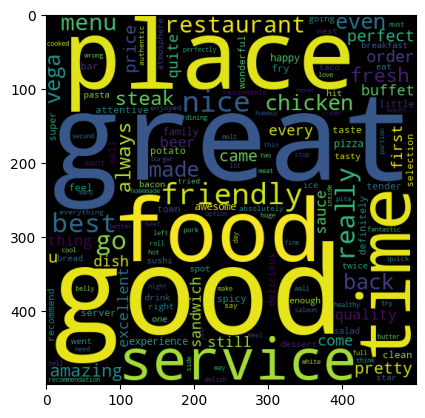

In [156]:
plt.imshow(pos)

In [157]:
pos1=wc.generate(data[data["Liked"]==0]['Process_data'].str.cat(sep=""))

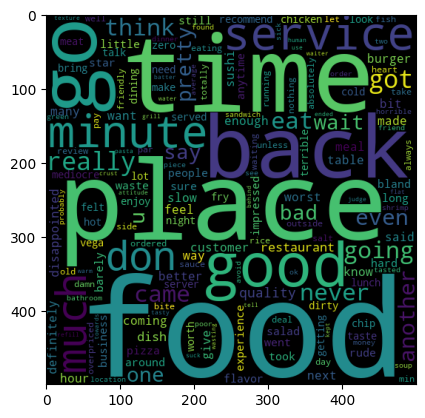

In [158]:
plt.imshow(pos1)

In [159]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=1500)

In [160]:
 X=cv.fit_transform(corpus).toarray()


In [161]:
X.shape

(1000, 1500)

In [162]:
y=data['Liked']

In [163]:
y

0      1
1      0
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Liked, Length: 1000, dtype: int64

In [164]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40)

In [165]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train,y_train)
joblib.dump(lr,'Model_Restaurant_CountVect(LR)')
y_pred=nb.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score

In [167]:
accuracy_score(y_test,y_pred)

0.69

In [168]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)
joblib.dump(cv,'Model_Restaurant_CountVect(LR)')
y_pred=lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.815

In [169]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.805

In [170]:
import joblib

In [171]:
joblib.dump(lr,'Model_RestaurantRevie(LR)')

['Model_RestaurantRevie(LR)']

In [172]:
import tkinter as tk
from tkinter import ttk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
import joblib
import re

class RestaurantReviewApp:
    def __init__(self, master):
        self.master = master
        master.title("Restaurant Review Classification App")
        master.geometry("400x300") 

        self.model = joblib.load('Model_RestaurantRevie(LR)')
        self.vectorizer = joblib.load('Model_Restaurant_CountVect(LR)')

        
        title_font = ('Helvetica', 16, 'bold')  # Larger font for the title
        self.label = ttk.Label(master, text="Enter your restaurant review:", font=title_font)
        self.label.pack(pady=10)

        self.text_entry = tk.Text(master, height=5, width=40)
        self.text_entry.pack(pady=10)

        self.classify_button = ttk.Button(master, text="Classify", command=self.classify_review, style='Custom.TButton')
        self.classify_button.pack(pady=10)

        self.result_label = ttk.Label(master, text="")
        self.result_label.pack(pady=10)

        self.style = ttk.Style()
        self.style.configure('Custom.TButton', font=('Helvetica', 12), width=15, foreground='black', background='#4CAF50', padding=(10, 5))
        self.style.map('Custom.TButton', foreground=[('pressed', 'black'), ('active', 'white')], background=[('pressed', '!disabled', '#45a049'), ('active', '#4CAF50')])

    def preprocess_text(self, text):
        custom_stopwords = {'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't",
                            'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't",
                            'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
                            'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't",
                            'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}
        ps = PorterStemmer()
        stop_words = set(stopwords.words("english")) - custom_stopwords

        review = re.sub('[^a-zA-Z]', ' ', text)
        review = review.lower()
        review = review.split()
        review = [ps.stem(word) for word in review if word not in stop_words]
        review = " ".join(review)

        return review

    def classify_review(self):
        user_input = self.text_entry.get("1.0", "end-1c")
        if user_input:
            processed_input = self.preprocess_text(user_input)
            processed_input_vectorized = self.vectorizer.transform([processed_input])
            prediction = self.model.predict(processed_input_vectorized)[0]
            sentiment = "Positive" if prediction == 1 else "Negative"
            self.result_label.config(text=f"Predicted Sentiment: {sentiment}")
        else:
            self.result_label.config(text="Please enter a review before clicking 'Classify'.")

if __name__ == "__main__":
    root = tk.Tk()
    app = RestaurantReviewApp(root)
    root.mainloop()